Load Libraries and set random seeds

In [29]:
from utils.imports import *

np.random.seed(42)

Set maps for CSI data files loading

In [30]:
#path: str = "C:\\Users\\pedro\\OneDrive - Universidade de Coimbra\\Ambiente de Trabalho\\tese\\thesis-project\\CSI DATA RENAMED [alterado]"
path: str = "C:\\Users\\Oscar\\Documents\\GitHub\\thesis-project_isac\\CSI DATA RENAMED [alterado]"

FileMap = Dict[str, Dict[str, str]]

csv_loureiro: FileMap = {}
csv_diana: FileMap = {}
csv_afinar: FileMap = {}

data_files = get_csv_files_generalistic(path)

*Define Functions*

Misc

In [31]:
def print_useful_info(file: FileMap) -> None:
	
	# Print information about the files dictionaries
	print("Número de ficheiros recolhidos em ", file, ":", len(file))
	
    # avoid StopIteration if dict is empty
	esp_count = len(next(iter(file.values()))) if file else 0
	print("ESPs por cenário:", esp_count)

	# Print all scenarios names
	print("\nTodos os cenários:", sorted(file.keys()))

	# Count scenarios by letter prefix
	scenario_prefixes: Dict[str, int] = {}
	for scenario in file:
		prefix = scenario[0]
		scenario_prefixes[prefix] = scenario_prefixes.get(prefix, 0) + 1

	print("\nScenarios count by prefix:")
	for prefix, count in sorted(scenario_prefixes.items()):
		print(f"Prefix {prefix}: {count} scenarios")

	print("\n")
	

In [4]:
print_useful_info(data_files)

Número de ficheiros recolhidos em  {'z00': {'esp_1': 'C:\\Users\\Oscar\\Documents\\GitHub\\thesis-project_isac\\CSI DATA RENAMED [alterado]\\02-z00-01-02.csv', 'esp_2': 'C:\\Users\\Oscar\\Documents\\GitHub\\thesis-project_isac\\CSI DATA RENAMED [alterado]\\02-z00-02-02.csv', 'esp_3': 'C:\\Users\\Oscar\\Documents\\GitHub\\thesis-project_isac\\CSI DATA RENAMED [alterado]\\02-z00-03-02.csv', 'esp_4': 'C:\\Users\\Oscar\\Documents\\GitHub\\thesis-project_isac\\CSI DATA RENAMED [alterado]\\02-z00-04-02.csv'}, 'a00': {'esp_1': 'C:\\Users\\Oscar\\Documents\\GitHub\\thesis-project_isac\\CSI DATA RENAMED [alterado]\\02-a00-01-01.csv', 'esp_2': 'C:\\Users\\Oscar\\Documents\\GitHub\\thesis-project_isac\\CSI DATA RENAMED [alterado]\\02-a00-02-01.csv', 'esp_3': 'C:\\Users\\Oscar\\Documents\\GitHub\\thesis-project_isac\\CSI DATA RENAMED [alterado]\\02-a00-03-01.csv', 'esp_4': 'C:\\Users\\Oscar\\Documents\\GitHub\\thesis-project_isac\\CSI DATA RENAMED [alterado]\\02-a00-04-01.csv'}, 'a01': {'esp_1': '

In [32]:

# função que processo o arquivo CSV completo
# # e extrai a info da coluna do CSI
# # converte em números complexos
# # calcula a magnitude (2.º passo)
# # 
# e faz ainda uma 1a limpeza
# # remove 2 primeiras subportadoras
# # remove colunas a zero
# # aplica FFT shift

# da tese
# # Vector size verification
# # Subcarrier layout and magnitude computation

csiMap = Dict[str, Dict[str, np.ndarray]]

def process_csi(file: str):
    df = pd.read_csv(file, header=None)
    csi_col = df.iloc[:, 26]

    valid_csi = []
    for entry in csi_col:
        match = re.search(r'\[(.*?)\]', str(entry))
        if not match:
            continue
        nums = [float(n) for n in re.findall(r'-?\d+', match.group(1))]
        if len(nums) == 128:
            valid_csi.append(nums)

    valid_csi = np.array(valid_csi)
    complex_csi = valid_csi[:, ::2] + 1j * valid_csi[:, 1::2]
    magnitudes = np.abs(complex_csi)

    # Limpeza: remover 2 primeiras subportadoras e colunas todas-zero
    magnitudes = magnitudes[:, 2:]
    magnitudes = magnitudes[:, ~np.all(magnitudes == 0, axis=0)]
    magnitudes = np.fft.fftshift(magnitudes, axes=1)

    return magnitudes

# cria o dict magnitudes
# itera sobre cada posicao da grelha
# # para cada posicao, itera sobre cada esp_id e path
# # devolve o dict magnitudes preenchido
def process_magnitudes(file: FileMap) -> Dict[str, Dict[str, np.ndarray]]:
    
    magnitudes: Dict[str, Dict[str, np.ndarray]] = {}

    for posicao in file:
        magnitudes[posicao] = {}

        # dict com "esp_id" e "path"
        esps = file[posicao]

        for esp_id, ficheiro in esps.items():
            magnitudes[posicao][esp_id] = process_csi(ficheiro)
            
    return magnitudes

# o dict magnitudes fica
# posicao1
# # esp1
# # # array de arrays (cada leitura é um array)
# # ...
# # esp4
# # # array de arrays (cada leitura é um array)


# cálculo das médias das subportadoras

# função que extrai valores de determiada subportadora
# # recolhe apenas uma fracção dos valores (1/6 * nº leituras)
# # e devolve um dicionário com os resultados
# # # dict esp: array de valores
def extrai_valores_sc(magnitudes_dict: csiMap, posicao: str, subcarrier: int, frac: float) -> Dict[str, np.ndarray]:
    resultados: Dict[str, np.ndarray] = {}
    n: int
    for esp, matriz in magnitudes_dict[posicao].items():
        n = int(matriz.shape[0] * frac)
        resultados[esp] = matriz[:n, subcarrier]

    return resultados

# função que calcula a média dos valores extraídos na função de cima
# retorna um dict com 
# # esp: média
# Nota: np.mean retorna um np.floating; para satisfazer o tipo Dict[str, float]
# convertemos explicitamente para float()
def calcular_media_sc(subportadora_dict: Dict[str, np.ndarray]) -> Dict[str, float]:
    return {esp: float(np.mean(valores)) for esp, valores in subportadora_dict.items()}

# função que calcula a média para cada subportadora
# # para cada sc
# # extrai os (n * frac) primeiros valores de cada esp
# # calcula a sua média 
# # # devolve um dict com
# # # subcarrier: {esp_y: média}
def calcular_medias_para_varias_subportadoras(magnitudes_dict: csiMap, posicao: str, subcarrier_indices: list[int], frac: float) -> Dict[int, Dict[str, float]]:
    medias_por_subc: Dict[int, Dict[str, float]] = {}
    for sc in subcarrier_indices:
        valores = extrai_valores_sc(magnitudes_dict, posicao, sc, frac)
        medias = calcular_media_sc(valores)
        medias_por_subc[sc] = medias
    return medias_por_subc


# para cada posição
# # ver o tamanho de cada (auto definido em cima)
# # e para cada subportadora
# # # e para cada esp
# # # # extrair o vetor correto
# # # # guardar no dicionário

dadosMap = Dict[int, Dict[str, np.ndarray]]

def criar_dataset(posicoes: list[str], magnitudes: csiMap) -> dadosMap:

    subcarriers: list[int] = list(range(51))
    dados: dadosMap = {}
    dados = {sc: {} for sc in subcarriers}
    
    for posicao in posicoes:
        for sc in subcarriers:
            for esp_id in range(1, 5):
                # acede ao array de arrays
                matriz = magnitudes[posicao][f'esp_{esp_id}']
                # extrai o vetor coluna
                # com (linhas/leituras = tamanho)
                # com (coluna = subc)
                vetor = matriz[:, sc]
                #print("nº linhas = ", matriz.shape[0], " e tamanho = ", tamanho)
                chave = f"{posicao}_esp_{esp_id}"
                dados[sc][chave] = vetor

    return dados

# Função para normalizar
# a função recebe o dicionário de vetores e o dicionário de médias
# e devolve o dicionário de vetores normalizados
# cada vetor é normalizado subtraindo a média e dividindo pela média
def normalizar_vetores(dados: dadosMap, medias: Dict[int, Dict[str, float]],posicoes) -> dadosMap:

    subcarriers: list[int] = list(range(51))
    esps_id: list[int] = [1, 2, 3, 4]

    normalizados: dadosMap = {}
    normalizados = {sc: {} for sc in subcarriers}

    for sc in subcarriers:
        for posicao in posicoes:
            for esp_id in esps_id:
                
                chave = f"{posicao}_esp_{esp_id}"
                vetor = dados[sc][chave]

                esp = f"esp_{esp_id}"
                media = medias[sc][esp]

                normalizados[sc][chave] = (vetor - media) / media
    return normalizados

# Função para normalizar dados a afinar
def normalizar_vetores_afinar(vetores: dadosMap, medias: Dict[int, Dict[str, float]]) -> dadosMap:

    subcarriers: list[int] = list(range(51))
    esps_id: list[int] = [1, 2, 3, 4]
    
    normalizados: dadosMap = {}
    normalizados = {sc: {} for sc in subcarriers}

    for sc in subcarriers:
        for posicao in posicoes_afinar:
            for esp_id in esps_id:

                chave = f"{posicao}_esp_{esp_id}"
                vetor = vetores[sc][chave]
                
                esp = f"esp_{esp_id}"
                media = medias[sc][esp]

                normalizados[sc][chave] = (vetor - media) / media
    return normalizados


# função para calcular a média em janelas sobrepostas
def media_grupos_overlap(vetor: np.ndarray, tamanho_janela: int, step: int) -> np.ndarray:
    medias: list[float] = []
    for i in range(0, len(vetor) - tamanho_janela + 1, step):
        janela = vetor[i:i + tamanho_janela]
        medias.append(float(np.mean(janela)))
    return np.array(medias)

# função para calcular o desvio padrão em janelas sobrepostas
def std_grupos_overlap(vetor: np.ndarray, tamanho_janela: int, step: int) -> np.ndarray:
    desvios: list[float] = []
    for i in range(0, len(vetor) - tamanho_janela + 1, step):
        janela = vetor[i:i + tamanho_janela]
        desvios.append(float(np.std(janela)))
    return np.array(desvios)

# função para calcular o máximo em janelas sobrepostas,
# evitando repetições dos últimos 3 máximos escolhidos
def max_grupos_overlap(vetor: np.ndarray, tamanho_janela: int, step: int) -> np.ndarray:
    maximos: list[float] = []
    for i in range(0, len(vetor) - tamanho_janela + 1, step):
        janela = vetor[i:i + tamanho_janela]
        candidatos = np.sort(np.unique(janela))[::-1]  # do maior para o menor

        # Exclui os 3 últimos valores
        ultimos = set(maximos[-3:])

        escolhido = None
        for val in candidatos:
            if val not in ultimos:
                escolhido = val
                break

        # Se todos os valores estão nos últimos 3, aceita o maior mesmo assim
        if escolhido is None:
            escolhido = candidatos[0]

        maximos.append(escolhido)

    return np.array(maximos)

def media_fixed(vetor: np.ndarray, tamanho_janela: int, W: int) -> np.ndarray:
    step = (len(vetor) - tamanho_janela) // (W - 1)
    return media_grupos_overlap(vetor, tamanho_janela, step)[:W]

def std_fixed(vetor: np.ndarray, tamanho_janela: int, W: int) -> np.ndarray:
    step = (len(vetor) - tamanho_janela) // (W - 1)
    return std_grupos_overlap(vetor, tamanho_janela, step)[:W]

def max_fixed(vetor: np.ndarray, tamanho_janela: int, W: int) -> np.ndarray:
    step = (len(vetor) - tamanho_janela) // (W - 1)
    return max_grupos_overlap(vetor, tamanho_janela, step)[:W]

CSI Load and Pre-processing

In [33]:
magnitudes: csiMap = {}
magnitudes = process_magnitudes(data_files)


# posição para retirar normalizações - escolha ARBITRÁRIA (explorar outras opções?)
posicao: str = 'c06'

# inicializa lista de subportadoras e números de ESPs
subcarriers: list[int] = list(range(51))
esps_id: list[int] = [1, 2, 3, 4]

# fração dos valores a considerar
frac: float = 1/6

medias: Dict[int, Dict[str, float]] = {}
medias = calcular_medias_para_varias_subportadoras(magnitudes, posicao, subcarriers, frac)


In [34]:
posicoes: list[str] = []
posicoes_afinar: list[str] = []

posicoes = ['z00', 'a00', 'a01', 'a09', 'a10', 'a11', 'b00', 'b01', 'b02',
        'b03', 'b04', 'b05', 'b06', 'b07', 'b08', 'b09', 'b10', 'b11', 'c01', 'c02', 'c03',
        'c04', 'c05', 'c06', 'c07', 'c08', 'c09', 'c10', 'c11', 'd01', 'd02', 'd03',
        'd04', 'd05', 'd06', 'd07', 'd08', 'd09', 'd10', 'd11', 'e04', 'e05', 'e06']

dados: dadosMap = {}
dados = criar_dataset(posicoes, magnitudes)

dados_normalizados: dadosMap = {}
dados_normalizados = normalizar_vetores(dados, medias, posicoes)


Cálculo de médias

In [35]:
subcarriers: list[int] = list(range(51))
tamanho_janela: int = 10
step: int = 3
W: int = 27 # Este valor precisa de ser estudado e ajustado consoante o tamanho dos vetores ?
G: int = 60 # Para vazio

medias_dados: dadosMap = {sc: {} for sc in subcarriers}
stds_dados: dadosMap = {sc: {} for sc in subcarriers}
maxs_dados: dadosMap = {sc: {} for sc in subcarriers}

for pos in posicoes:
    for esp_id in esps_id:
        chave = f"{pos}_esp_{esp_id}"
        for sc in subcarriers:
            vetor = dados_normalizados[sc][chave]

            if pos == 'z00':
                media_1 = media_grupos_overlap(vetor, tamanho_janela, W)
                std_1 = std_grupos_overlap(vetor, tamanho_janela, W)
                max_1 = max_grupos_overlap(vetor, tamanho_janela, W)

            else:
                media1 = media_fixed(vetor, tamanho_janela, W)
                std1 = std_fixed(vetor, tamanho_janela, W)
                max1 = max_fixed(vetor, tamanho_janela, W)

            medias_dados[sc][chave] = media_1
            stds_dados[sc][chave] = std_1
            maxs_dados[sc][chave] = max_1



In [ ]:
# Célula para codigo de testes / debug 

Célula a baixo ainda não está a funcionar

In [18]:
# Deal with class imbalanceo of the dataset before doing a train/test split by undersampling the majority class while preserving the same ammount of samples from different positions and ESPs

# First count the number of samples in each position per ESP class
from traitlets import List


position_esp_counts: Dict[str, int] = {}
for pos in posicoes:
    for esp_id in esps_id:
        key = f"{pos}_esp_{esp_id}"
        count = len(medias_dados[22][key])  # usando subportadora 22 como referência
        position_esp_counts[key] = count

# Now sum counts per position across ESPs
position_counts: Dict[str, int] = {}
for pos in posicoes:
    total_count = sum(position_esp_counts[f"{pos}_esp_{esp_id}"] for esp_id in esps_id)
    position_counts[pos] = total_count

# Find the minimum count among all positions per ESP (excluding the 'z00')
min_count: int = min(count for pos, count in position_esp_counts.items() if pos != 'z00')

# Find the number of samples that each class can have after undersampling to match z00
n_samples_per_class: int = position_counts['z00'] // (len(posicoes) - 1)

# Random sample from each position per ESP to match the undersampled size or the minimum count
selected_indices: List[int] = []    
current_index: int = 0

for pos in posicoes:
    for esp_id in esps_id:
        key = f"{pos}_esp_{esp_id}"
        count = position_esp_counts[key]

        if pos == 'z00':
            continue  # skip z00

        else:
            if len(medias_dados[22][key]) > min_count:
                n_to_sample = n_samples_per_class // 4  # divide by number of ESPs
            else:
                n_to_sample = min_count

        indices = list(range(current_index, current_index + count))
        sampled_indices = np.random.choice(indices, size=n_to_sample, replace=False)
        selected_indices.extend(sampled_indices)

        current_index += count

# Create the new dictionary with undersampled data
medias_dados_undersampled: dadosMap = {sc: {} for sc in subcarriers}
svd_dados_undersampled: dadosMap = {sc: {} for sc in subcarriers}
maxs_dados_undersampled: dadosMap = {sc: {} for sc in subcarriers}

for sc in subcarriers:
    for pos in posicoes:
        for esp_id in esps_id:
            chave = f"{pos}_esp_{esp_id}"
            vetor_media = medias_dados[sc][chave]
            vetor_std = stds_dados[sc][chave]
            vetor_max = maxs_dados[sc][chave]

            medias_dados_undersampled[sc][chave] = vetor_media[np.isin(
                np.arange(len(vetor_media)), selected_indices)]
            svd_dados_undersampled[sc][chave] = vetor_std[np.isin(
                np.arange(len(vetor_std)), selected_indices)]
            maxs_dados_undersampled[sc][chave] = vetor_max[np.isin(
                np.arange(len(vetor_max)), selected_indices)]

medias_dados = medias_dados_undersampled
stds_dados = svd_dados_undersampled
maxs_dados = maxs_dados_undersampled



In [36]:
subcarriers_map: dict[int, str] = {i + 1: sc for i, sc in enumerate(subcarriers)}

# dicionarios para colunas
coluna_media: dict[str, np.ndarray] = {}
coluna_std: dict[str, np.ndarray] = {}
coluna_max: dict[str, np.ndarray] = {}

for sc_label, sc in subcarriers_map.items():
    for esp_id in esps_id:
        # nome da coluna
        name_mean = f"sc_{sc_label}_esp_{esp_id}_mean"
        name_std = f"sc_{sc_label}_esp_{esp_id}_std"
        name_max = f"sc_{sc_label}_esp_{esp_id}_max"

        sequencia_mean, sequencia_std, sequencia_max = [], [], []

        for pos in posicoes:
            key = f"{pos}_esp_{esp_id}"

            sequencia_mean.append(medias_dados[sc][key])
            sequencia_std.append(stds_dados[sc][key])
            sequencia_max.append(maxs_dados[sc][key])

        # Concatena as colunas 
        coluna_media[name_mean] = np.concatenate(sequencia_mean)
        coluna_std[name_std] = np.concatenate(sequencia_std)
        coluna_max[name_max] = np.concatenate(sequencia_max)


In [37]:
all_cols: dict[str, np.ndarray] = {**coluna_media, **coluna_std, **coluna_max}
min_len: int = min(len(v) for v in all_cols.values())   

# trunca todas as colunas para min_len
coluna_media = {k: v[:min_len] for k, v in coluna_media.items()}
coluna_std = {k: v[:min_len] for k, v in coluna_std.items()}
coluna_max = {k: v[:min_len] for k, v in coluna_max.items()}

# gerar um vetor de labels -  0 = vazio, 1 = pessoa presente
# numero de zeros é o numero de leituras na posicao z00
n_zero: int = sum([len(medias_dados[22][f"z00_esp_{esp_id}"]) for esp_id in esps_id])

# numero total de leituras depois de truncado é min_len
n_total: int = min_len

# Criar vetor de labels
labels: np.ndarray = np.zeros(n_total, dtype=int)
labels[n_zero:] = 1  # definir os restantes como 1 (pessoa presente)

# criar DataFrame final
df: pd.DataFrame = pd.DataFrame({**coluna_media, **coluna_std, **coluna_max})
df['label'] = labels

# To check:
print("DataFrame shape:", df.shape)
print(df.shape)
df.describe()

DataFrame shape: (427, 613)
(427, 613)


,sc_1_esp_1_mean,sc_1_esp_2_mean,sc_1_esp_3_mean,sc_1_esp_4_mean,sc_2_esp_1_mean,sc_2_esp_2_mean,sc_2_esp_3_mean,sc_2_esp_4_mean,sc_3_esp_1_mean,sc_3_esp_2_mean,...,sc_49_esp_4_max,sc_50_esp_1_max,sc_50_esp_2_max,sc_50_esp_3_max,sc_50_esp_4_max,sc_51_esp_1_max,sc_51_esp_2_max,sc_51_esp_3_max,sc_51_esp_4_max,label
count,427.000000,427.000000,427.000000,427.000000,427.000000,427.000000,427.000000,427.000000,427.000000,427.000000,...,427.000000,427.000000,427.000000,427.000000,427.000000,427.000000,427.000000,427.000000,427.000000,427.000000
mean,-0.130191,-0.132402,-0.132285,-0.133962,-0.129929,-0.132588,-0.132420,-0.133674,-0.129982,-0.132244,...,0.103304,0.093929,0.089750,0.095974,0.101735,0.094642,0.099800,0.092720,0.091243,0.922717
std,0.098321,0.099105,0.096110,0.096740,0.098619,0.097507,0.095780,0.097722,0.098526,0.096892,...,0.095064,0.055458,0.048968,0.058735,0.086117,0.053603,0.103658,0.050543,0.047776,0.267354
min,-0.261723,-0.323635,-0.261723,-0.295518,-0.261723,-0.282607,-0.261723,-0.310836,-0.261723,-0.261723,...,-0.005710,-0.005710,-0.046525,-0.005710,-0.005710,-0.005710,-0.005710,-0.111094,-0.005710,0.000000
25%,-0.192242,-0.192242,-0.192242,-0.192242,-0.192242,-0.192242,-0.192242,-0.192242,-0.192242,-0.192242,...,0.059460,0.059460,0.059460,0.059460,0.059460,0.059460,0.059460,0.059460,0.059460,1.000000
50%,-0.143739,-0.184792,-0.143739,-0.188971,-0.143739,-0.187340,-0.143739,-0.188971,-0.143739,-0.143739,...,0.108567,0.108567,0.104444,0.108567,0.108567,0.108567,0.108567,0.108567,0.104444,1.000000
75%,-0.075915,-0.075915,-0.075915,-0.075915,-0.075915,-0.075915,-0.075915,-0.075915,-0.075915,-0.075915,...,0.135676,0.135676,0.135676,0.135676,0.135676,0.135676,0.135676,0.135676,0.135676,1.000000
max,0.113409,0.294884,0.027407,0.027407,0.112641,0.097627,0.027407,0.097685,0.089733,0.076464,...,0.720773,0.616466,0.158219,0.428526,0.687121,0.353530,1.755969,0.241347,0.158219,1.000000


In [38]:
# X e Y - features e labels
# Divisão de treino e teste com rácio 80-20
X: np.ndarray = df.drop(columns='label').values
Y: np.ndarray = df['label'].values

# --- IGNORE ---
print(("X shape:", X.shape))
print(("Y shape:", Y.shape))

X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42, stratify=Y)

print(("X_train shape:", X_train.shape))
print(("Y_train shape:", Y_train.shape))
print(("X_test shape:", X_test.shape))
print(("Y_test shape:", Y_test.shape))

('X shape:', (427, 612))
('Y shape:', (427,))
('X_train shape:', (341, 612))
('Y_train shape:', (341,))
('X_test shape:', (86, 612))
('Y_test shape:', (86,))


#### Random Forest Classifier

In [39]:
model = RandomForestClassifier(min_samples_split=4,
                                min_samples_leaf=4,
                                max_leaf_nodes=64,
                                n_estimators=150,
                                random_state = 200,
                                max_depth=16,
                                class_weight="balanced_subsample",
                                criterion='entropy'
)

model = model.fit(X_train, Y_train)

y_pred = model.predict(X_test)

# Note that while balanced_accuracy_score is used, if the dataset is imbalanced training could be affected.
ball_acc = balanced_accuracy_score(Y_test, y_pred)
print("Balanced Accuracy:", ball_acc)

Balanced Accuracy: 0.6428571428571428


In [40]:
confusion_matrix_test = confusion_matrix(Y_test, y_pred)

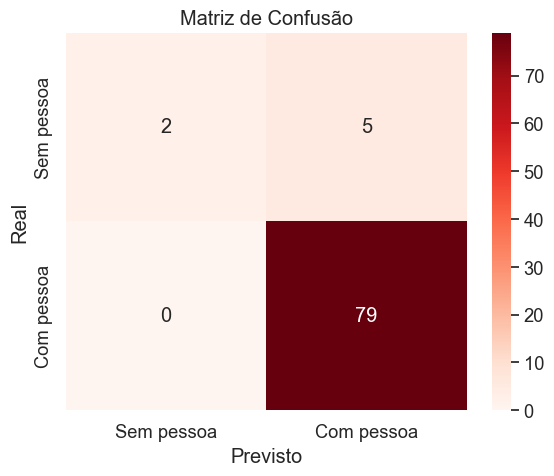

In [41]:
sns.set(font_scale=1.2)
plt.figure(figsize=(6, 5))

sns.heatmap(confusion_matrix_test, annot=True, fmt='d', cmap='Reds',
            xticklabels=["Sem pessoa", "Com pessoa"],
            yticklabels=["Sem pessoa", "Com pessoa"])

plt.title("Matriz de Confusão")
plt.xlabel("Previsto")
plt.ylabel("Real")
plt.tight_layout()
plt.show()

In [16]:
# Grid Search 
# 432 combinações
param_grid = {
    'min_samples_split': [4, 16, 32],
    'min_samples_leaf': [4, 16, 32, 64],
    'max_leaf_nodes': [4, 16, 32, 64],
    'n_estimators': [100, 150, 200],
    'max_depth': [4, 16, 32]
}

rf = RandomForestClassifier(
    random_state=200,
    class_weight="balanced_subsample",
    criterion='entropy'
)

scorer = make_scorer(balanced_accuracy_score)

grid_search = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    scoring=scorer,
    cv=5,
    n_jobs=-1,
    verbose=2
)

# fit
grid_search.fit(X_train, Y_train)

# Best model and parameters
print("Best balanced accuracy:", grid_search.best_score_)
print("Best params:", grid_search.best_params_)

# Predict with best model
best_model = grid_search.best_estimator_
y_pred = best_model.predict(X_test)
print("Test balanced accuracy:", balanced_accuracy_score(Y_test, y_pred))

Fitting 5 folds for each of 432 candidates, totalling 2160 fits
Best balanced accuracy: 0.6533333333333332
Best params: {'max_depth': 4, 'max_leaf_nodes': 4, 'min_samples_leaf': 4, 'min_samples_split': 4, 'n_estimators': 100}
Test balanced accuracy: 0.6428571428571428
